# Relax-ensemble peptide design — analysis

Phase 1 of the 2P5E pipeline: OpenMM produced **12 relaxed backbone conformations** of the full
pMHC-TCR complex, and ProteinMPNN designed the peptide (chain C, native `SLLMWITQC`, **no Met@P1**)
on each. This notebook focuses on the *conformational* dimension the single-structure run can't show:

1. Load per-backbone designs + inventory
2. Per-backbone score / diversity
3. Ensemble per-position frequencies & logo
4. **Conformational robustness** — which positions are conserved across conformations vs conformation-dependent
5. Per-backbone consensus sequences
6. vs native (identity, per-position recovery, P1 check)
7. Ensemble vs single-structure (mpnn_50k) design profile
8. Sequence space colored by backbone

Robust to partial data — re-run anytime while the MPNN sweep is still going.

In [1]:
from pathlib import Path
ROOT   = Path("/home/ubuntu/if-mhc")
RELAX_SEQS = ROOT/"outputs/relax_campaign/seqs"      # one <snapshot>.fa per conformation
SINGLE_FA  = ROOT/"outputs/mpnn_50k/seqs/2P5E.fa"    # single-structure reference (Phase 0)
NATIVE = "SLLMWITQC"
FIGDIR = ROOT/"outputs/relax_campaign/figures"; FIGDIR.mkdir(parents=True, exist_ok=True)
ANCHORS = [2, 9]

In [2]:
import re, glob, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
try: from IPython.display import display
except Exception: display = print
warnings.filterwarnings("ignore"); sns.set_style("whitegrid"); plt.rcParams["figure.dpi"]=110
AA = list("ACDEFGHIKLMNPQRSTVWY"); AA_IDX = {a:i for i,a in enumerate(AA)}

def load_fasta(path):
    rows, native = [], None
    p=Path(path)
    if not p.exists(): return pd.DataFrame(), None
    ls=p.read_text().splitlines()
    for i in range(0,len(ls)-1,2):
        h,s=ls[i],ls[i+1].strip()
        if not h.startswith(">"): continue
        if "sample=" not in h: native=s; continue
        d=dict(re.findall(r'(\w+)=([-\d.]+)',h))
        rows.append({"peptide":s,"score":float(d.get("score","nan")),
                     "global_score":float(d.get("global_score","nan")),
                     "seq_recovery":float(d.get("seq_recovery","nan"))})
    return pd.DataFrame(rows), native

def freq_matrix(seqs, L):
    M=np.zeros((L,len(AA)))
    for s in seqs:
        for i,c in enumerate(s):
            if c in AA_IDX: M[i,AA_IDX[c]]+=1
    M/=M.sum(1,keepdims=True)
    return pd.DataFrame(M,columns=AA,index=list(range(L)))

## 1. Load per-backbone designs

In [3]:
parts=[]
for fa in sorted(glob.glob(str(RELAX_SEQS/"*.fa"))):
    bb=Path(fa).stem
    d,_=load_fasta(fa)
    if len(d): d["backbone"]=bb; parts.append(d)
df=pd.concat(parts,ignore_index=True) if parts else pd.DataFrame()
L=len(NATIVE)
df=df[df.peptide.str.len()==L].reset_index(drop=True)
backbones=sorted(df.backbone.unique()) if len(df) else []
print(f"backbones loaded: {len(backbones)}  ({', '.join(backbones)})")
print(f"total designs: {len(df):,} | unique: {df.peptide.nunique():,} | L={L} | native={NATIVE}")
df.head()

backbones loaded: 12  (snap_00, snap_01, snap_02, snap_03, snap_04, snap_05, snap_06, snap_07, snap_08, snap_09, snap_10, snap_11)
total designs: 24,000 | unique: 15,962 | L=9 | native=SLLMWITQC


,peptide,score,global_score,seq_recovery,backbone
0,LFLSYVALV,2.0439,1.8561,0.1111,snap_00
1,ELIAYENRV,1.7174,1.8648,0.1111,snap_00
2,RLISYDYLL,1.7228,1.8427,0.1111,snap_00
3,ELLAWDWRV,1.7256,1.8654,0.3333,snap_00
4,ELIAFDYRF,1.6917,1.8411,0.1111,snap_00


In [4]:
inv=df.groupby("backbone").agg(n=("peptide","size"), unique=("peptide","nunique"),
        mean_score=("score","mean"), met_at_P1=("peptide", lambda s:(s.str[0]=='M').sum())).round(3)
display(inv)
print("Met@P1 total across ensemble (should be 0):", int((df.peptide.str[0]=='M').sum()))

,n,unique,mean_score,met_at_P1
backbone,,,,
snap_00,2000,1876,1.800,0
snap_01,2000,930,1.551,0
snap_02,2000,1891,1.938,0
snap_03,2000,1558,1.777,0
snap_04,2000,798,1.461,0
snap_05,2000,1375,1.869,0
snap_06,2000,1101,1.662,0
snap_07,2000,1585,1.886,0
snap_08,2000,1152,1.637,0


Met@P1 total across ensemble (should be 0): 0


## 2. Per-backbone score & diversity

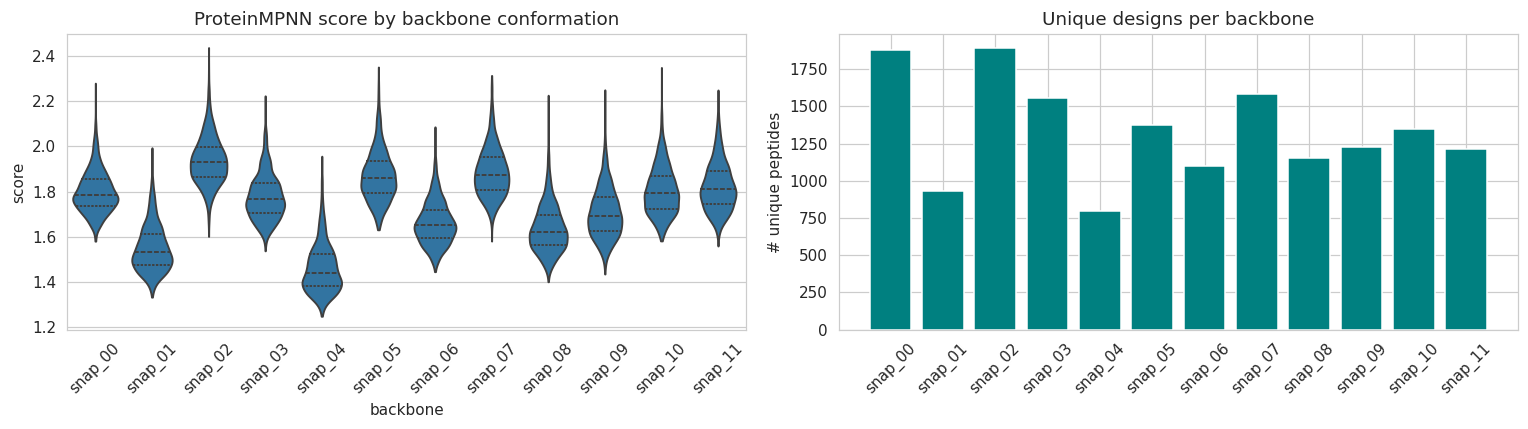

In [5]:
fig,ax=plt.subplots(1,2,figsize=(14,4))
order=backbones
sns.violinplot(data=df,x="backbone",y="score",order=order,ax=ax[0],cut=0,inner="quartile")
ax[0].set_title("ProteinMPNN score by backbone conformation"); ax[0].tick_params(axis='x',rotation=45)
uq=df.groupby("backbone").peptide.nunique().reindex(order)
ax[1].bar(range(len(order)),uq.values,color="teal"); ax[1].set_xticks(range(len(order)))
ax[1].set_xticklabels(order,rotation=45); ax[1].set_ylabel("# unique peptides")
ax[1].set_title("Unique designs per backbone")
plt.tight_layout(); plt.savefig(FIGDIR/"per_backbone_stats.png",bbox_inches="tight"); plt.show()

## 3. Ensemble per-position frequency & logo

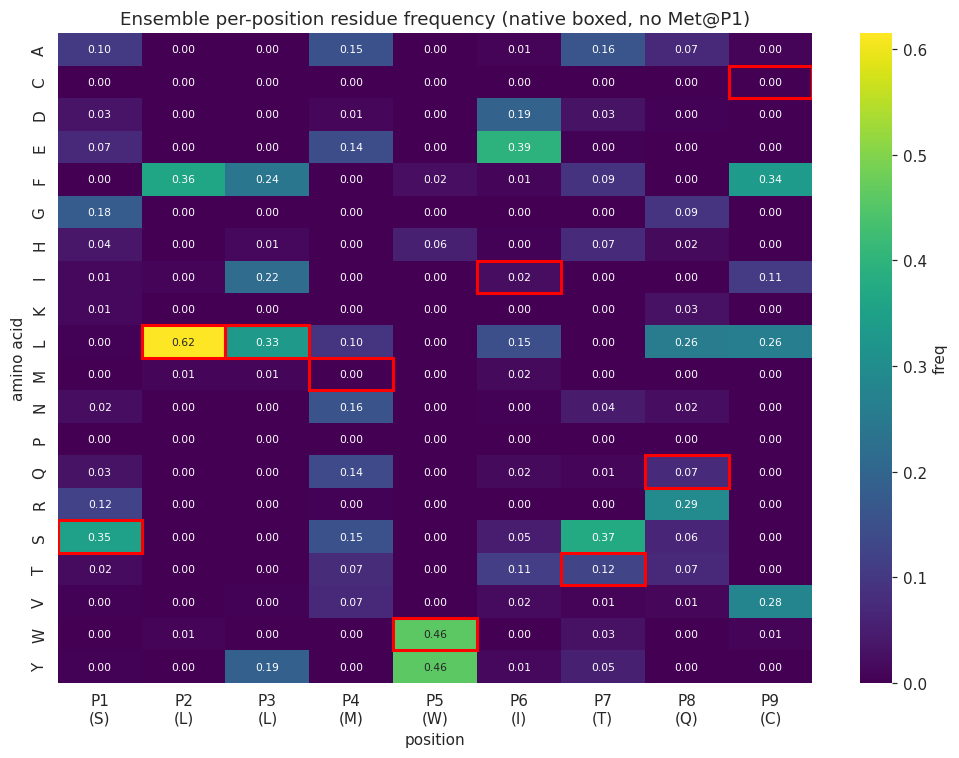

In [6]:
freq=freq_matrix(df.peptide.values,L)
fig,ax=plt.subplots(figsize=(0.7*L+3,7))
sns.heatmap(freq.T,cmap="viridis",annot=True,fmt=".2f",annot_kws={"size":7},
            xticklabels=[f"P{i+1}\n({NATIVE[i]})" for i in range(L)],yticklabels=AA,
            cbar_kws={"label":"freq"},ax=ax)
for i,c in enumerate(NATIVE):
    if c in AA_IDX: ax.add_patch(plt.Rectangle((i,AA_IDX[c]),1,1,fill=False,ec="red",lw=2))
ax.set_title("Ensemble per-position residue frequency (native boxed, no Met@P1)")
ax.set_xlabel("position"); ax.set_ylabel("amino acid")
plt.tight_layout(); plt.savefig(FIGDIR/"ensemble_freq.png",bbox_inches="tight"); plt.show()

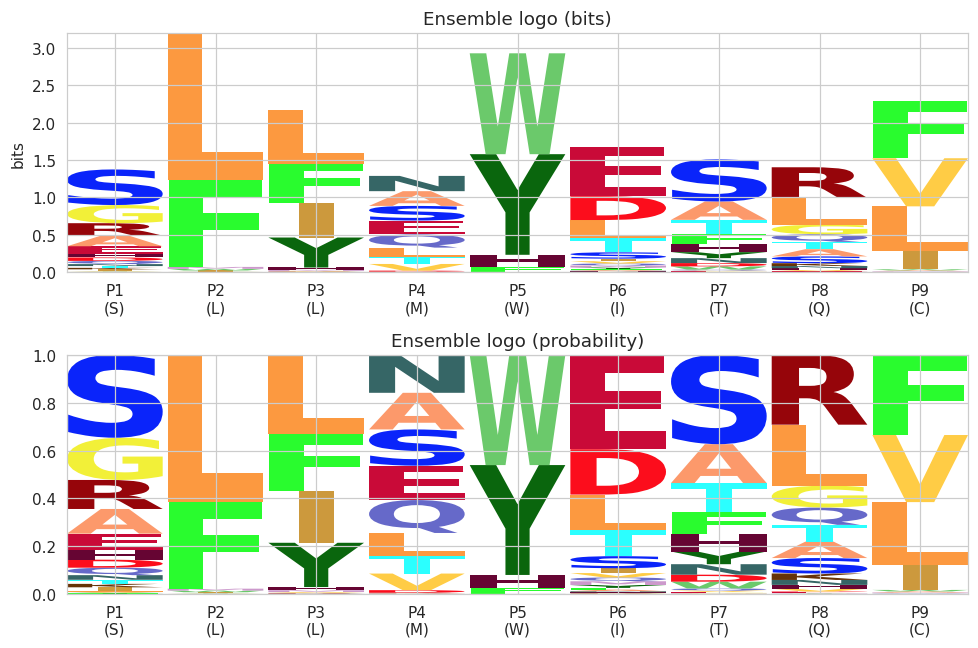

In [7]:
import logomaker
info=logomaker.transform_matrix(freq.copy(),from_type="probability",to_type="information")
fig,axes=plt.subplots(2,1,figsize=(max(6,L),6))
logomaker.Logo(info,ax=axes[0],color_scheme="skylign_protein"); axes[0].set_title("Ensemble logo (bits)"); axes[0].set_ylabel("bits")
logomaker.Logo(freq.copy(),ax=axes[1],color_scheme="skylign_protein"); axes[1].set_title("Ensemble logo (probability)")
for a in axes: a.set_xticks(range(L)); a.set_xticklabels([f"P{i+1}\n({NATIVE[i]})" for i in range(L)])
plt.tight_layout(); plt.savefig(FIGDIR/"ensemble_logo.png",bbox_inches="tight"); plt.show()

## 4. Conformational robustness

For each position: how much do the per-backbone design profiles **agree** across conformations?
We compare the ensemble (pooled) entropy to the mean within-backbone entropy, and measure the
spread of each backbone's top-residue frequency. High spread = conformation-dependent position.

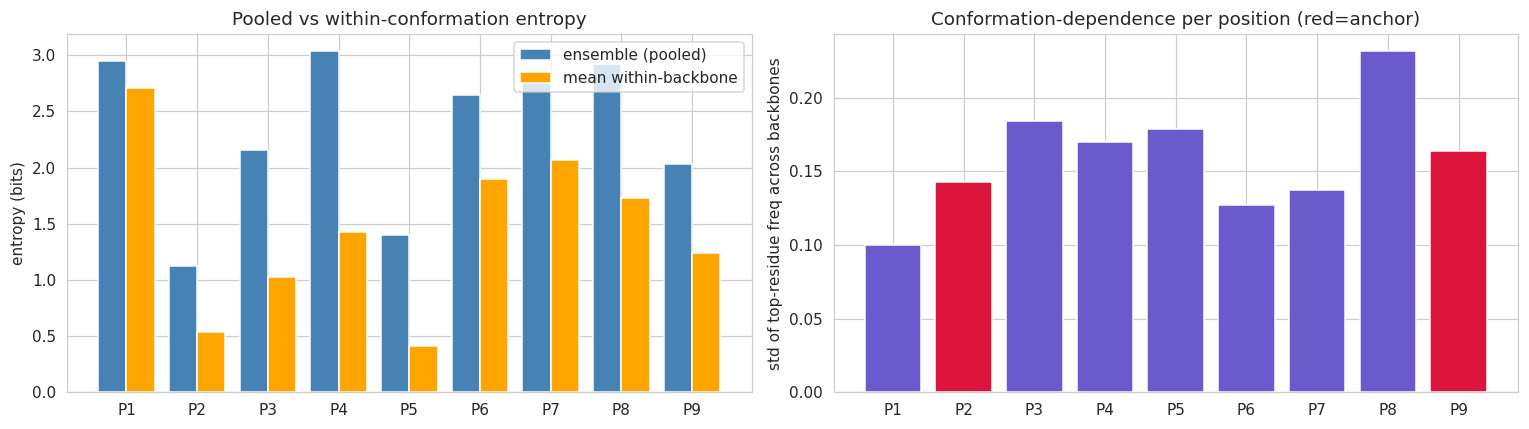

Most conformation-dependent positions: ['P8', 'P3', 'P5']


In [8]:
eps=1e-12
# per-backbone frequency matrices
bbF={bb:freq_matrix(df[df.backbone==bb].peptide.values,L) for bb in backbones}
ens_ent=-(freq*np.log2(freq+eps)).sum(1).values
mean_bb_ent=np.mean([-(bbF[bb]*np.log2(bbF[bb]+eps)).sum(1).values for bb in backbones],axis=0)
# spread across backbones of the dominant-residue frequency per position
top_per_bb=np.array([bbF[bb].max(1).values for bb in backbones])  # [n_bb, L]
spread=top_per_bb.std(0)

fig,ax=plt.subplots(1,2,figsize=(14,4))
x=np.arange(L); w=0.4
ax[0].bar(x-w/2,ens_ent,w,label="ensemble (pooled)",color="steelblue")
ax[0].bar(x+w/2,mean_bb_ent,w,label="mean within-backbone",color="orange")
ax[0].set_xticks(x); ax[0].set_xticklabels([f"P{i+1}" for i in range(L)])
ax[0].set_ylabel("entropy (bits)"); ax[0].legend(); ax[0].set_title("Pooled vs within-conformation entropy")
colors=["crimson" if (i+1) in ANCHORS else "slateblue" for i in range(L)]
ax[1].bar([f"P{i+1}" for i in range(L)],spread,color=colors)
ax[1].set_ylabel("std of top-residue freq across backbones")
ax[1].set_title("Conformation-dependence per position (red=anchor)")
plt.tight_layout(); plt.savefig(FIGDIR/"conformational_robustness.png",bbox_inches="tight"); plt.show()
print("Most conformation-dependent positions:",
      [f"P{i+1}" for i in np.argsort(spread)[::-1][:3]])

## 5. Per-backbone consensus sequences

,backbone,consensus,%id_to_native
0,snap_00,ELIAYDAQV,22.2
1,snap_01,SFLAWDYRF,33.3
2,snap_02,SFINWESLF,22.2
3,snap_03,SLLEYDSRL,33.3
4,snap_04,SFLQYDSLL,22.2
5,snap_05,SLYSHLSSF,22.2
6,snap_06,SLFQYESRL,22.2
7,snap_07,SLYLYEFRL,22.2
8,snap_08,SLLVWESGF,44.4
9,snap_09,SFFLWLSLV,22.2


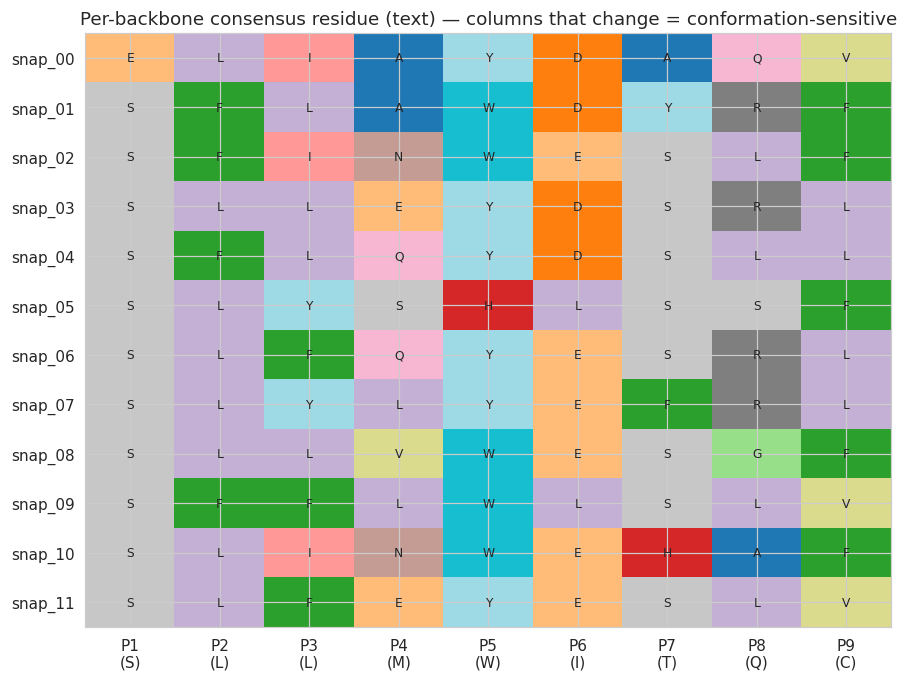

In [9]:
rows=[]
for bb in backbones:
    f=bbF[bb]; cons="".join(AA[f.iloc[i].values.argmax()] for i in range(L))
    rows.append({"backbone":bb,"consensus":cons,
                 "%id_to_native":round(100*sum(a==b for a,b in zip(cons,NATIVE))/L,1)})
cons_df=pd.DataFrame(rows); display(cons_df)
# consensus agreement matrix: position x backbone, colored by residue
import matplotlib.colors as mcolors
M=np.array([[AA_IDX.get(cons_df.consensus[j][i],-1) for i in range(L)] for j in range(len(backbones))])
fig,ax=plt.subplots(figsize=(0.7*L+2,0.4*len(backbones)+1.5))
im=ax.imshow(M,cmap="tab20",aspect="auto")
ax.set_xticks(range(L)); ax.set_xticklabels([f"P{i+1}\n({NATIVE[i]})" for i in range(L)])
ax.set_yticks(range(len(backbones))); ax.set_yticklabels(backbones)
for j in range(len(backbones)):
    for i in range(L): ax.text(i,j,cons_df.consensus[j][i],ha="center",va="center",fontsize=8)
ax.set_title("Per-backbone consensus residue (text) — columns that change = conformation-sensitive")
plt.tight_layout(); plt.savefig(FIGDIR/"consensus_by_backbone.png",bbox_inches="tight"); plt.show()

## 6. Comparison with native

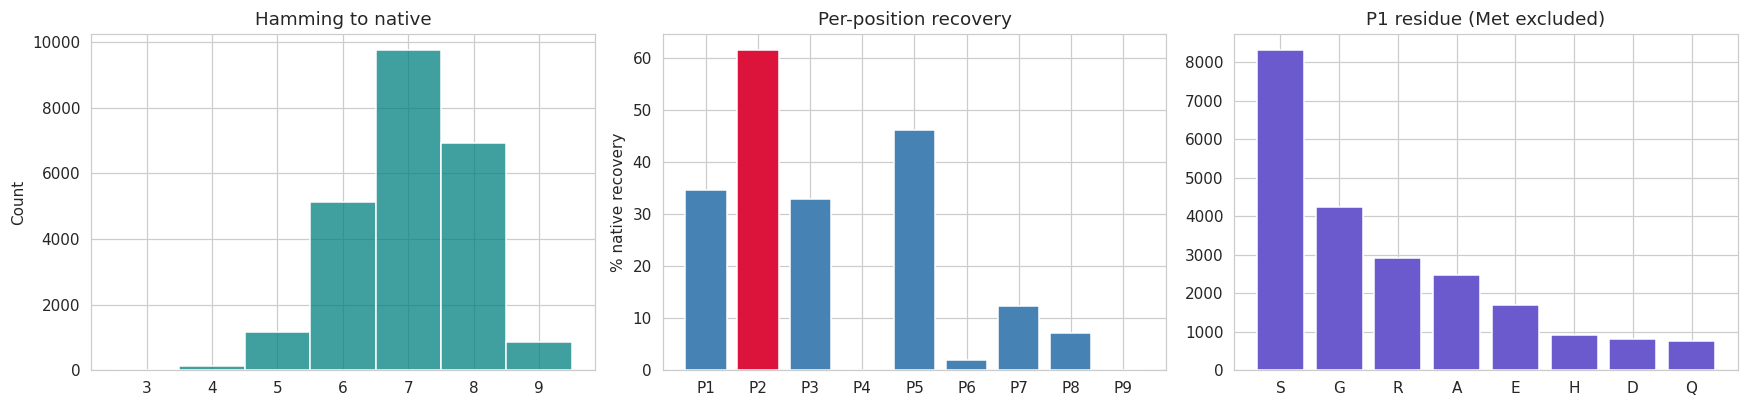

mean identity to native: 21.9%


In [10]:
nat=np.array(list(NATIVE)); P=np.array([list(s) for s in df.peptide])
ham=(P!=nat).sum(1); df["identity"]=1-ham/L
fig,ax=plt.subplots(1,3,figsize=(16,3.8))
sns.histplot(ham,bins=range(0,L+2),discrete=True,ax=ax[0],color="teal"); ax[0].set_title("Hamming to native")
rec=(P==nat).mean(0); cols=["crimson" if (i+1) in ANCHORS else "steelblue" for i in range(L)]
ax[1].bar([f"P{i+1}" for i in range(L)],rec*100,color=cols); ax[1].set_ylabel("% native recovery"); ax[1].set_title("Per-position recovery")
p1=df.peptide.str[0].value_counts().head(8)
ax[2].bar(p1.index,p1.values,color="slateblue"); ax[2].set_title("P1 residue (Met excluded)")
plt.tight_layout(); plt.savefig(FIGDIR/"vs_native.png",bbox_inches="tight"); plt.show()
print(f"mean identity to native: {100*df.identity.mean():.1f}%")

## 7. Ensemble vs single-structure design profile

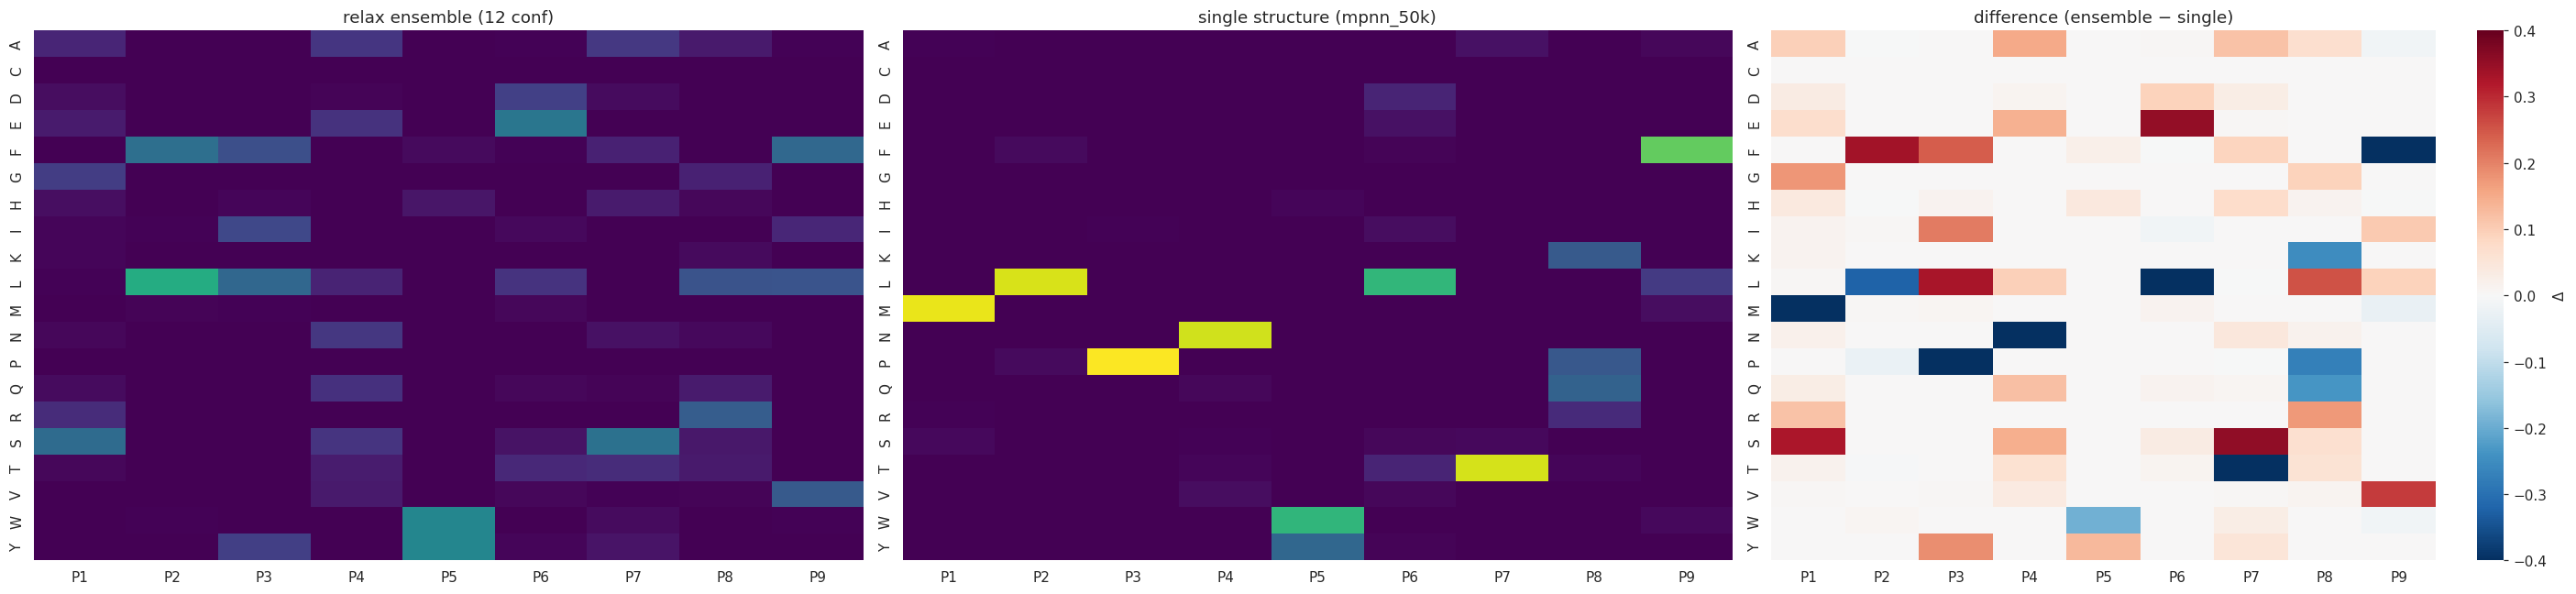

Note: single-structure mpnn_50k allowed Met@P1; expect a large P1 difference there.


In [11]:
ds,_=load_fasta(SINGLE_FA)
if len(ds):
    ds=ds[ds.peptide.str.len()==L]
    sF=freq_matrix(ds.peptide.values,L)
    fig,ax=plt.subplots(1,3,figsize=(2.0*L+8,6))
    for a,(M,t) in zip(ax[:2],[(freq,"relax ensemble (12 conf)"),(sF,"single structure (mpnn_50k)")]):
        sns.heatmap(M.T,cmap="viridis",vmin=0,vmax=1,ax=a,cbar=False,
                    xticklabels=[f"P{i+1}" for i in range(L)],yticklabels=AA); a.set_title(t)
    sns.heatmap((freq-sF).T,cmap="RdBu_r",center=0,vmin=-.4,vmax=.4,ax=ax[2],
                xticklabels=[f"P{i+1}" for i in range(L)],yticklabels=AA,cbar_kws={"label":"Δ"})
    ax[2].set_title("difference (ensemble − single)")
    plt.tight_layout(); plt.savefig(FIGDIR/"ensemble_vs_single.png",bbox_inches="tight"); plt.show()
    print("Note: single-structure mpnn_50k allowed Met@P1; expect a large P1 difference there.")
else:
    print("single-structure reference not found.")

## 8. Sequence space (colored by backbone)

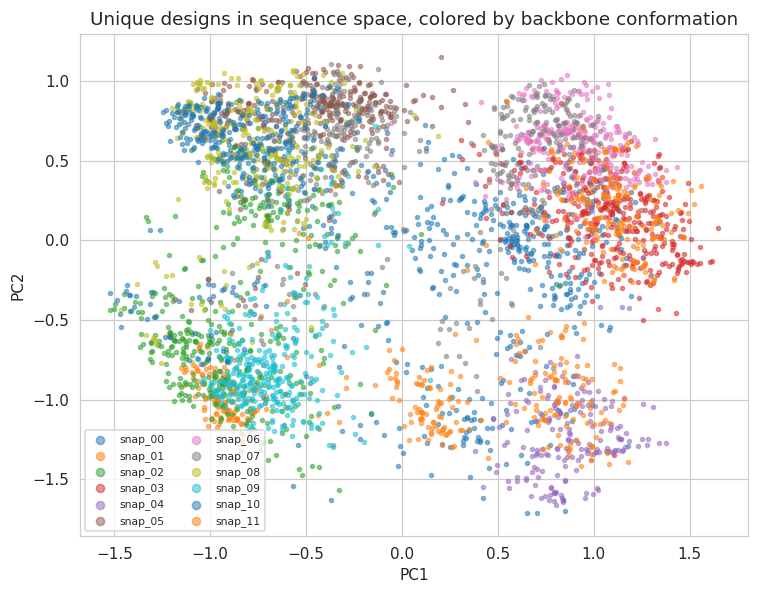

In [12]:
from sklearn.decomposition import PCA
def onehot(seqs,L):
    X=np.zeros((len(seqs),L*len(AA)),dtype=np.float32)
    for r,s in enumerate(seqs):
        for i,c in enumerate(s):
            if c in AA_IDX: X[r,i*len(AA)+AA_IDX[c]]=1
    return X
uniq=df.drop_duplicates("peptide").reset_index(drop=True)
sub=uniq.sample(min(4000,len(uniq)),random_state=0) if len(uniq)>4000 else uniq
X=onehot(sub.peptide.values,L); pc=PCA(2,random_state=0).fit_transform(X)
sub=sub.assign(pc1=pc[:,0],pc2=pc[:,1])
fig,ax=plt.subplots(figsize=(7,5.5))
for bb in backbones:
    m=sub.backbone==bb
    ax.scatter(sub.pc1[m],sub.pc2[m],s=7,alpha=.5,label=bb)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.legend(fontsize=7,ncol=2,markerscale=2)
ax.set_title("Unique designs in sequence space, colored by backbone conformation")
plt.tight_layout(); plt.savefig(FIGDIR/"sequence_space_by_backbone.png",bbox_inches="tight"); plt.show()

## 9. Summary & exports

In [13]:
import json
summary={"backbones":len(backbones),"total_designs":int(len(df)),"unique":int(df.peptide.nunique()),
         "met_at_P1":int((df.peptide.str[0]=='M').sum()),
         "mean_identity_to_native_pct":round(100*df.identity.mean(),2),
         "best_score":round(float(df.score.min()),4),
         "best_design":df.loc[df.score.idxmin(),"peptide"]}
print(json.dumps(summary,indent=2))
df.sort_values("score").drop_duplicates("peptide").head(100).to_csv(ROOT/"outputs/relax_campaign/top100_by_score.csv",index=False)
freq.to_csv(ROOT/"outputs/relax_campaign/ensemble_position_frequency.csv")
display(df.sort_values("score").drop_duplicates("peptide").head(10)[["peptide","backbone","score","identity"]])

{
  "backbones": 12,
  "total_designs": 24000,
  "unique": 15962,
  "met_at_P1": 0,
  "mean_identity_to_native_pct": 21.87,
  "best_score": 1.2495,
  "best_design": "SFLQYDSLL"
}


,peptide,backbone,score,identity
8223,SFLQYDSLL,snap_04,1.2495,0.222222
8301,SFLQYDSLV,snap_04,1.2571,0.222222
8454,SFLQYTSLL,snap_04,1.2702,0.222222
9649,GFLQYDSLL,snap_04,1.2822,0.111111
8711,SFLQYDFLL,snap_04,1.2915,0.222222
9972,SFLQYTTLL,snap_04,1.2999,0.333333
9334,GFLQYDSLV,snap_04,1.3016,0.111111
9693,SFLQYTSLV,snap_04,1.3058,0.222222
8213,SFLQYDFLV,snap_04,1.3061,0.222222
8042,GFLQYDFLL,snap_04,1.3105,0.111111
